# ```sampley``` exemplar: the point approach
Before going through this exemplar, please consult the Introduction to sampley exemplars (```intro.ipynb```).
<br>This exemplar illustrates an application of the point approach using the 'from-the-line' variation to data contained within two files: one containing survey tracks (```sections.gpkg```) and one containing sightings data (```sightings_off-line.gpkg```).

## Setup

### Import the package

In [1]:
from sampley import *

### Set the import folder
To run this exemplar, download the mock data files, put them in a folder, and set the path to the folder below.

In [2]:
import_folder = './import/'

### Set the export folder
To run this exemplar, make a folder to save the samples in and set the path to the folder below.

In [3]:
export_folder = './export/'

## Stage 1
In Stage 1, we import two files (```sightings.csv``` and ```sections.gpkg```) and from them make a ```DataPoints``` and a ```Sections``` object, respectively.
<br>Although we use a CSV file and a GPKG file in this exemplar, there are other options for file types (including XLSX and SHP files). Please see the Stage 1 exemplar (```stage-1.ipynb```) in the horizontal exemplars folder or the User Manual for more details. Note that, regardless of the imported file type, once any ```DataPoints``` and/or ```Sections``` objects have been made, the subsequent processing will be the same.

In [4]:
u_sightings = DataPoints.from_file(
    filepath=import_folder+'sightings_off-line.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: datapoint IDs generated.


In [5]:
u_sections = Sections.from_file(
    filepath=import_folder+'sections.gpkg',
    crs_working='EPSG:32619',
    datetime_col='datetime',
    tz_import='UTC-05:00'
)

Success: file opened.
Success: reprojected to CRS "EPSG:32619"
Success: column "datetime" reformatted to datetimes.
Success: timezone of column "datetime" set to "UTC-05:00".
Success: section IDs generated.


## Stage 2
In the first part of Stage 2, we use the ```DataPoints``` object containing sightings data to make a ```Presences``` object (```u_presences```).

In [6]:
u_presences = Presences.delimit(
    datapoints=u_sightings,
    presence_col='individuals')

In [7]:
u_presences.presences[:5]  # print the first five rows of the presences GeoDataFrame

,point_id,point,date,datapoint_id
0,p01,POINT (579247.275 4743823.394),2019-01-25,d01
1,p02,POINT (555739.203 4737785.585),2019-01-25,d02
2,p03,POINT (548277.347 4745661.195),2019-01-25,d03
3,p04,POINT (521883.134 4723148.616),2019-03-02,d04
4,p05,POINT (537262.152 4720806.487),2019-03-02,d05


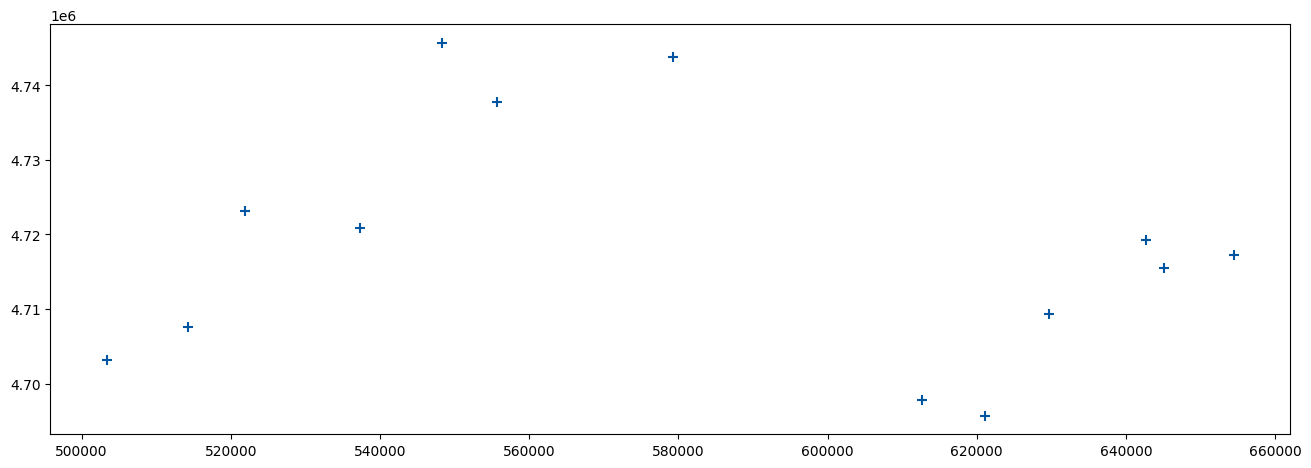

In [8]:
u_presences.plot()  # plot the presences

Then, we use the ```Presences``` object and the ```Sections``` object to make a ```PresenceZones``` object (```u_presencezones```) based on a spatial threshold of 10000 m and a temporal threshold of 5 days.

In [9]:
u_presencezones = PresenceZones.delimit(
    sections=u_sections,
    presences=u_presences,
    sp_threshold=10000,
    tm_threshold=5,
    tm_unit='day',
)

In [10]:
u_presencezones.presencezones  # print the presence zones GeoDataFrame

,section_id,presencezones
0,s1,"MULTIPOLYGON (((565691.051 4736805.413, 565547..."
1,s2,"MULTIPOLYGON (((565691.051 4736805.413, 565547..."
2,s3,"MULTIPOLYGON (((630730.025 4692794.346, 630399..."
3,s4,"MULTIPOLYGON (((630730.025 4692794.346, 630399..."


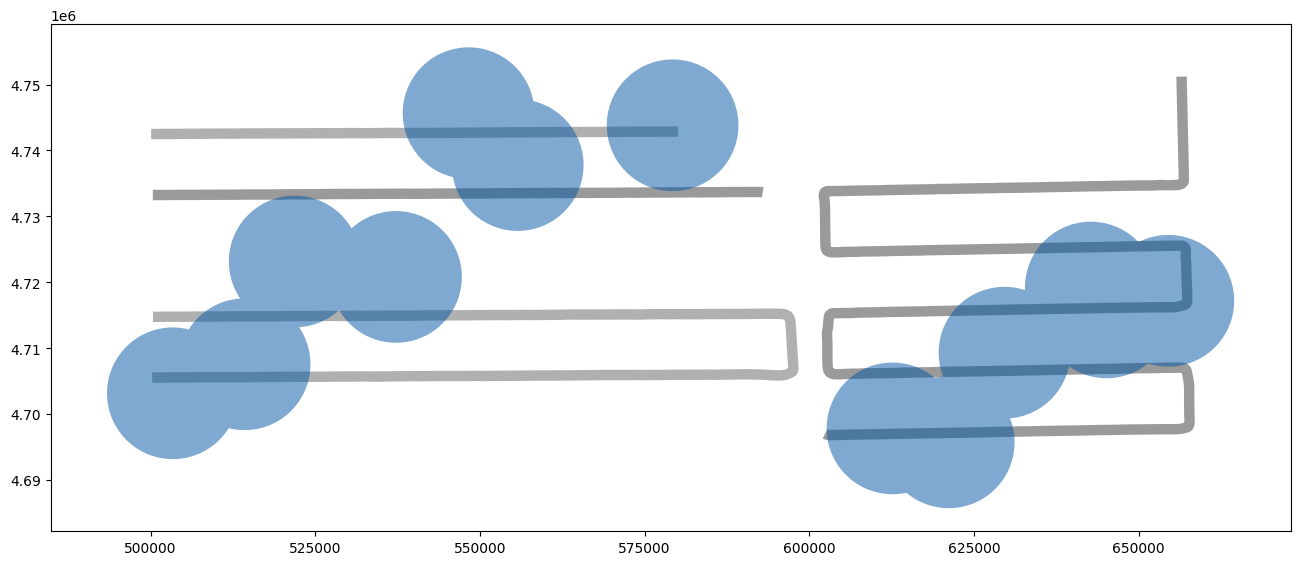

In [11]:
u_presencezones.plot(sections=u_sections)  # plot the presence zones (in blue) over the sections (in grey)

Before we generate absences with the from-the-line variation, we need some distances from the line that we can select from when generating the absences. These distances should simply be a list of values and can be made either in ```sampley``` or beforehand with any software and imported.
<br>Here, we make them with the following cells.

The first step is to set a detection function. Normally, this would be derived with specialised software, but here, for the sake of the example, we make a mock one with the following cell.

In [12]:
from math import exp
def detection_func(x): return exp((-x**2) / (2*500**2))

Now, we enter that distance function to the ```generate_dfls``` function. We also specify the number of candidate distances that we want to generate, the effective stripwidth, and the interval between candidate distances.

In [13]:
number = 100000
esw = 2000
interval = 1
from sampley.functions import generate_dfls
dfls = generate_dfls(number=number, esw=esw, interval=interval, dfunc=detection_func)

We can now inspect the distances that we generated.

In [14]:
print(f'Number of candidate distances: {len(dfls)}')
dfls[:5]

Number of candidate distances: 100000


[146.0, 14.0, 42.0, 716.0, 701.0]

We can also plot a histogram of the distances to see that they follow the detection function - nearer distances are more frequent, and so more likely to be selected, than further distances.

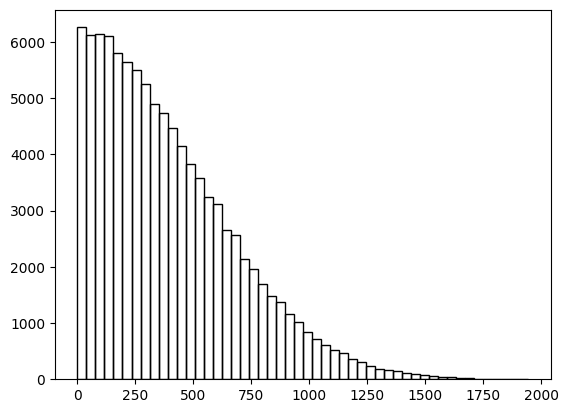

In [15]:
import matplotlib.pyplot as plt
plt.hist(dfls, bins=50, facecolor='none', edgecolor='black');

Now, we use the ```Sections``` object and the ```PresenceZones``` object to make an ```Absences``` object (```u_absences```).
<br>Note that the target number of absences to generate is set to five times the number of presences.
<br>We also enter the distances from the line that we just generated.

In [16]:
u_absences = Absences.delimit(
    sections=u_sections,
    presencezones=u_presencezones,
    var='from',
    target=5*len(u_presences.presences),
    dfls=dfls)

Target: 65 | Attempts: 118 | Successes: 65


In [17]:
u_absences.absences[:5]  # print the first five rows of the absences GeoDataFrame

,point_id,point,date,section_id,dfbs,point_al
0,a01,POINT (567432.051 4742840.9),2019-01-25,s1,12663.647511,POINT (567430.7585173511 4742806.924812923)
1,a02,POINT (566516.295 4742879.312),2019-01-25,s1,13577.732204,POINT (566516.9327843098 4742813.315206207)
2,a03,POINT (534237.9 4742581.72),2019-01-25,s1,45859.530952,POINT (534237.6458643199 4742632.7189303385)
3,a04,POINT (531937.435 4742241.664),2019-01-25,s1,48161.525032,POINT (531935.6783580296 4742621.660270202)
4,a05,POINT (523348.859 4741985.069),2019-01-25,s1,56751.719214,POINT (523346.76702083205 4742606.065544677)


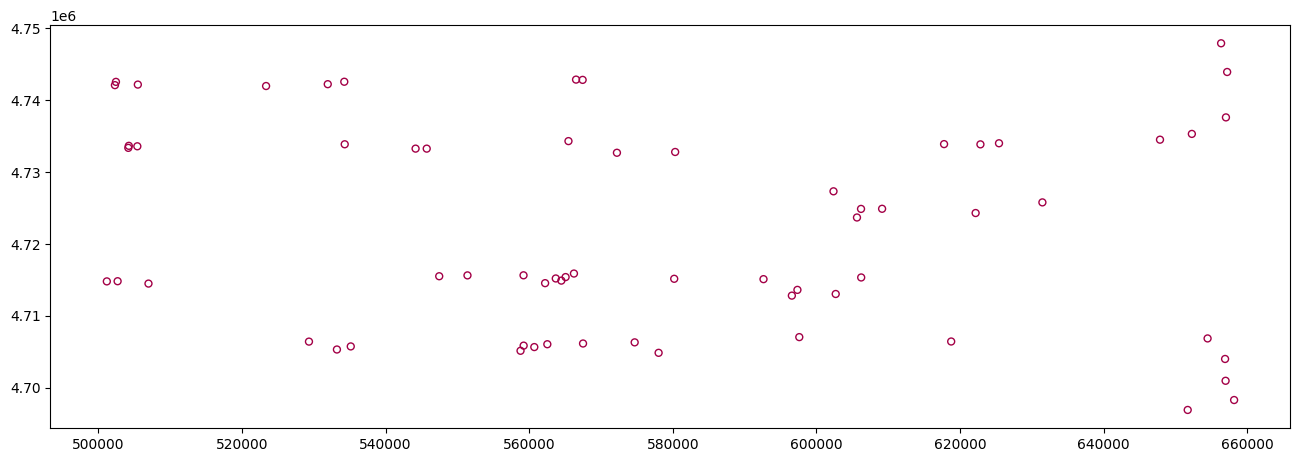

In [18]:
u_absences.plot()  # plot the absences

## Stage 3
In Stage 3, we make a ```Samples``` object from the ```Presences``` object and the ```Absences``` object. We also import the ```DataPoints``` object that contains the data to assign to the presences and a list of the data columns to assign.
<br>_Note that assigning data to the absences is not possible given the imported data. It is only possible if the absences are made from sections that are made from continuous datapoints (see the ```point-continuous.ipynb``` exemplar)._

In [19]:
u_samples = Samples.point(
    presences=u_presences,
    absences=u_absences,
    datapoints_p=u_sightings,  # DataPoints object containing data to assign to the presences
    cols_p=['individuals'])  # data columns in datapoints_p to assign to the presences

In [20]:
print(f'Number of samples: {len(u_samples.samples)}')

Number of samples: 78


In [21]:
u_samples.samples[:5]  # print the first five rows of the samples GeoDataFrame

,point_id,point,date,datapoint_id,p-a,individuals,point_al,section_id,dfbs
0,p01,POINT (579247.275 4743823.394),2019-01-25,d01,1,1.0,NaN,NaN,NaN
1,p02,POINT (555739.203 4737785.585),2019-01-25,d02,1,2.0,NaN,NaN,NaN
2,p03,POINT (548277.347 4745661.195),2019-01-25,d03,1,5.0,NaN,NaN,NaN
3,p04,POINT (521883.134 4723148.616),2019-03-02,d04,1,1.0,NaN,NaN,NaN
4,p05,POINT (537262.152 4720806.487),2019-03-02,d05,1,2.0,NaN,NaN,NaN


We know that, due to the presence zones, no absence will be within the spatial and temporal thresholds of a presence, however, by looking at the plots of the presences in Stage 2 above, we may see that some of the presences are close to other presences. The same applies to the absences. This may lead to issues associated with autocorrelation.
<br>So, here, we thin the samples with a spatial threshold of 10000 m and a temporal threshold of 5 days, resulting in 25 samples that are kept (within the ```samples``` attribute).

In [22]:
u_samples.thin(
    coords='point', 
    sp_threshold=10000,
    datetimes='date',
    tm_threshold=5,
    tm_unit='day'
)

In [23]:
print(f'Number of samples kept: {len(u_samples.samples)}')

Number of samples kept: 34


In [24]:
u_samples.samples[:5]  # print the first five rows of the samples GeoDataFrame

,point_id,point,date,datapoint_id,p-a,individuals,point_al,section_id,dfbs
0,p01,POINT (579247.275 4743823.394),2019-01-25,d01,1,1.0,NaN,NaN,NaN
1,p02,POINT (555739.203 4737785.585),2019-01-25,d02,1,2.0,NaN,NaN,NaN
2,p03,POINT (548277.347 4745661.195),2019-01-25,d03,1,5.0,NaN,NaN,NaN
3,p04,POINT (521883.134 4723148.616),2019-03-02,d04,1,1.0,NaN,NaN,NaN
4,p05,POINT (537262.152 4720806.487),2019-03-02,d05,1,2.0,NaN,NaN,NaN


Those samples that were removed by thinning are now in a new attribute: ```removed```.

In [25]:
print(f'Number of samples removed: {len(u_samples.removed)}')

Number of samples removed: 44


In [26]:
u_samples.removed[:5]  # print the first five rows of the removed samples GeoDataFrame

,point_id,point,date,datapoint_id,p-a,individuals,point_al,section_id,dfbs
0,p09,POINT (645110.432 4715423.485),2019-03-05,d09,1,2.0,NaN,NaN,NaN
1,p12,POINT (621160.621 4695697.192),2019-03-05,d12,1,2.0,NaN,NaN,NaN
2,a01,POINT (567432.051 4742840.9),2019-01-25,NaN,0,NaN,POINT (567430.7585173511 4742806.924812923),s1,12663.647511
3,a04,POINT (531937.435 4742241.664),2019-01-25,NaN,0,NaN,POINT (531935.6783580296 4742621.660270202),s1,48161.525032
4,a06,POINT (505489.22 4742185.928),2019-01-25,NaN,0,NaN,POINT (505488.94307461404 4742530.927752977),s1,74610.467412


## Export
Finally, we save the final ```Samples``` object to the export folder.

In [27]:
u_samples.save(
    folder=export_folder,
    filetype='csv',
    crs_export='EPSG:4326'
)

Success: reprojected to CRS "EPSG:4326"


In the export folder, there should be two new CSVs: the first should have the same name as the ```Samples``` object (run the box below to see the name) while the second should also have this name but with ```-parameters``` added at the end.

In [28]:
u_samples.name

'samples-presences-sightings_off-line-+-absences-fs-10000m-5day'

The first CSV should contain the samples, like those shown in the box below. 
<br>In this dataframe, each row represents a given presence or absence, i.e., a sample. 
<br>The column ```point``` delimits the location of the presence/absence.
<br>In this particular example, the data columns are ```p-a``` (presence-absence), ```individuals```, and ```bss```.

In [29]:
u_samples.samples

,point_id,point,date,datapoint_id,p-a,individuals,point_al,section_id,dfbs
0,p01,POINT (579247.275 4743823.394),2019-01-25,d01,1,1.0,NaN,NaN,NaN
1,p02,POINT (555739.203 4737785.585),2019-01-25,d02,1,2.0,NaN,NaN,NaN
2,p03,POINT (548277.347 4745661.195),2019-01-25,d03,1,5.0,NaN,NaN,NaN
3,p04,POINT (521883.134 4723148.616),2019-03-02,d04,1,1.0,NaN,NaN,NaN
4,p05,POINT (537262.152 4720806.487),2019-03-02,d05,1,2.0,NaN,NaN,NaN
5,p06,POINT (514284.369 4707549.723),2019-03-02,d06,1,1.0,NaN,NaN,NaN
6,p07,POINT (503390.874 4703145.523),2019-03-02,d07,1,3.0,NaN,NaN,NaN
7,p08,POINT (654496.459 4717184.616),2019-03-05,d08,1,5.0,NaN,NaN,NaN
8,p10,POINT (642728.973 4719199.855),2019-03-05,d10,1,1.0,NaN,NaN,NaN
9,p11,POINT (629622.26 4709308.371),2019-03-05,d11,1,3.0,NaN,NaN,NaN


The second CSV should contain the parameters, like those shown in the box below (but arranged in a table). This information may prove useful if, later, we need to know  how the samples were generated.

In [30]:
u_samples.parameters

{'approach': 'point',
 'resampled': 'datapoints',
 'presences_name': 'presences-sightings_off-line',
 'presences_crs': 'EPSG:32619',
 'absences_name': 'absences-fs-10000m-5day',
 'absences_var': 'from',
 'absences_target': 65,
 'presencezones_crs': 'EPSG:32619',
 'presencezones_sp_threshold': 10000,
 'presencezones_tm_threshold': 5,
 'presencezones_tm_unit': 'day',
 'sp_threshold': 10000,
 'tm_threshold': 5,
 'tm_unit': 'day'}